# imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", None)

In [2]:
csv_path = Path(r"C:\Users\user\Desktop\div\data\files\housing.csv")
df = pd.read_csv(csv_path)
df.head(3)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY


# outliers

### simple

In [3]:
outliers1 = df['median_house_value'] == df['median_house_value'].max()
outliers2 = df['housing_median_age'] == df['housing_median_age'].max()
outliers = outliers1 | outliers2


In [4]:
df = df.loc[~outliers, :].copy()
print(df.shape)
df.head(3)

(18572, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
8,-122.26,37.84,42.0,2555.0,665.0,1206.0,595.0,2.0804,226700.0,NEAR BAY


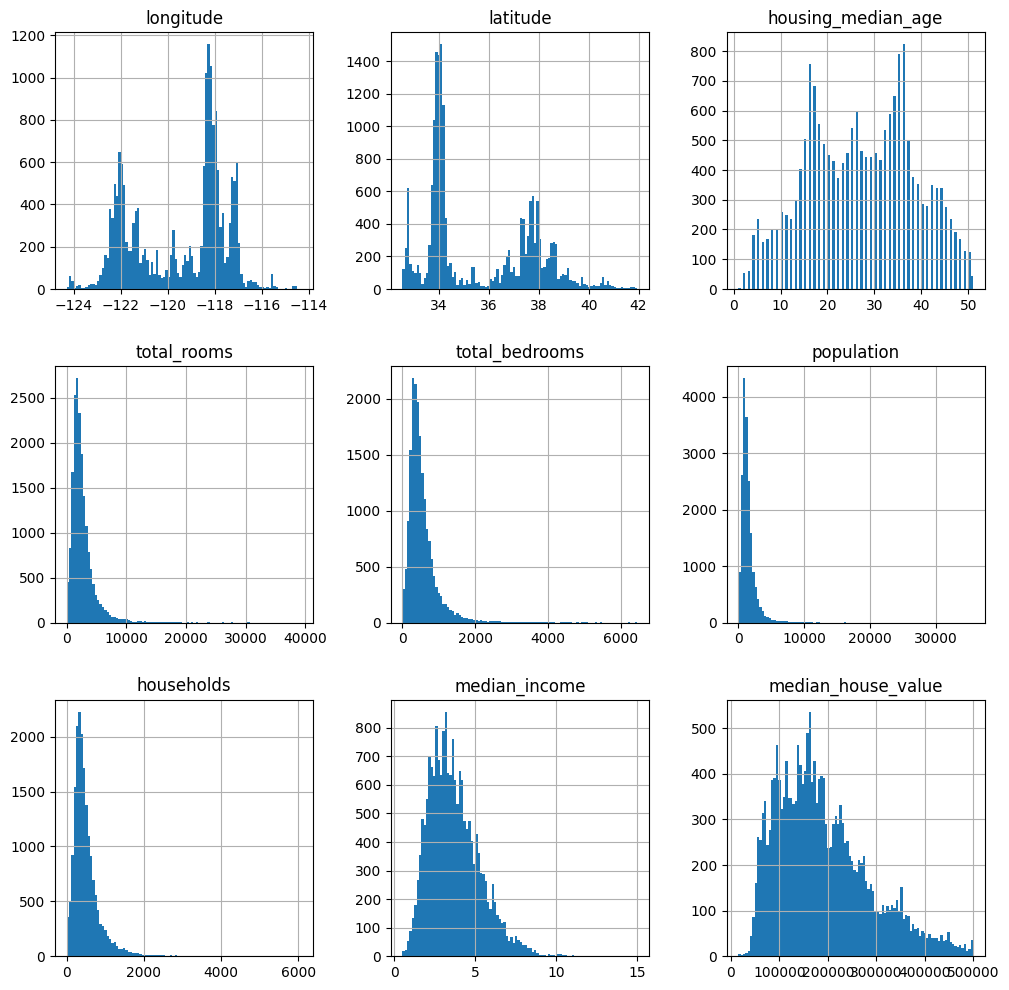

In [5]:
df.select_dtypes(include=['number']).hist(bins=100, figsize=(12, 12))
plt.show()

# split

In [6]:
X = df.drop('median_house_value', axis='columns')
y = df['median_house_value']

In [7]:
X['income_cat'] = pd.cut(
    X['median_income'],
    bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
    labels=[1, 2, 3, 4, 5]
    )

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    stratify=X['income_cat'],
    test_size=0.2
    )

X_train.shape, X_test.shape

((14857, 10), (3715, 10))

In [9]:
X_train.drop('income_cat', axis='columns', inplace=True)
X_test.drop('income_cat', axis='columns', inplace=True)

# pipeline

In [11]:
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.cluster import KMeans

n_clusters = 10
kmeans_ = KMeans(n_clusters = n_clusters)
kmeans_.fit(X_train[['latitude', 'longitude']])
print(kmeans_.cluster_centers_)

[[  32.8700834  -116.97268385]
 [  37.67526757 -122.15291425]
 [  34.55825994 -118.73879699]
 [  36.5929375  -119.5812875 ]
 [  38.91455945 -121.30427716]
 [  34.05343621 -117.16024691]
 [  40.35665842 -123.01876238]
 [  37.71894089 -120.99916256]
 [  34.89101227 -120.27291411]
 [  33.94725806 -118.11876543]]


In [13]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.cluster import KMeans

class ClusterSimilarity(BaseEstimator, TransformerMixin):
    def __init__(self, n_clusters=10):
        self.n_clusters = n_clusters

    def fit(self, X, y=None):
        self.kmeans_ = KMeans(self.n_clusters)
        self.kmeans_.fit(X)
        return self  

    def transform(self, X):
        return rbf_kernel(X, self.kmeans_.cluster_centers_, gamma=1).round(3)

    def get_feature_names_out(self, names=None):
        return [f"Cluster {i} similarity" for i in range(self.n_clusters)]

In [14]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

cat_cols = ['ocean_proximity']
log_cols = [
    'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income'
    ]

cat_pipeline = Pipeline([
    ('imp', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore'))
])
log_pipeline = Pipeline([
    ('imp', SimpleImputer(strategy='median')),
    ('log', FunctionTransformer(np.log1p, inverse_func=np.expm1, feature_names_out='one-to-one')),
    ('scl', StandardScaler())
])

def ratio_func(arr_2d):
    return arr_2d[:, [0]] / arr_2d[:, [1]]
def ratio_feature_names(*args, **kwargs):
    return ['ratio']

rat_pipeline = Pipeline([
    ('imp', SimpleImputer(strategy='median')),
    ('newcol', FunctionTransformer(ratio_func, feature_names_out=ratio_feature_names)),
    ('scl', StandardScaler())
])
cluster_pipeline = Pipeline([
    ('imp', SimpleImputer(strategy='median')),
    ('cluster', ClusterSimilarity(n_clusters=10))
])
num_pipeline = Pipeline([
    ('imp', SimpleImputer(strategy='median')),
    ('scl', StandardScaler())
])

preprocessing = ColumnTransformer(
    transformers=[
        ('CAT', cat_pipeline, cat_cols),
        ('LOG', log_pipeline, log_cols),
        ('RAT_b/r', rat_pipeline, ['total_bedrooms', 'total_rooms']),
        ('RAT_r/h', rat_pipeline, ['total_rooms', 'households']),
        ('RAT_p/h', rat_pipeline, ['population', 'households']),
        ("GEO", cluster_pipeline, ["latitude", "longitude"]),
    ], remainder=num_pipeline
)

X_train_arr = preprocessing.fit_transform(X_train)
X_train_prepared = pd.DataFrame(X_train_arr, columns=preprocessing.get_feature_names_out())

X_test_arr = preprocessing.fit_transform(X_test)
X_test_prepared = pd.DataFrame(X_test_arr, columns=preprocessing.get_feature_names_out())

X_train_prepared

,CAT__ocean_proximity_<1H OCEAN,CAT__ocean_proximity_INLAND,CAT__ocean_proximity_NEAR BAY,CAT__ocean_proximity_NEAR OCEAN,LOG__total_rooms,LOG__total_bedrooms,LOG__population,LOG__households,LOG__median_income,RAT_b/r__ratio,RAT_r/h__ratio,RAT_p/h__ratio,GEO__Cluster 0 similarity,GEO__Cluster 1 similarity,GEO__Cluster 2 similarity,GEO__Cluster 3 similarity,GEO__Cluster 4 similarity,GEO__Cluster 5 similarity,GEO__Cluster 6 similarity,GEO__Cluster 7 similarity,GEO__Cluster 8 similarity,GEO__Cluster 9 similarity,remainder__housing_median_age
0,1.0,0.0,0.0,0.0,-0.658679,-0.837127,-0.592942,-0.674042,0.870337,-0.472851,-0.097946,-0.008255,0.000,0.662,0.000,0.000,0.000,0.156,0.114,0.965,0.000,0.000,0.700980
1,0.0,1.0,0.0,0.0,-0.867766,-1.370237,-1.178433,-1.328197,1.110248,-1.101326,0.699456,0.003447,0.363,0.000,0.000,0.855,0.002,0.000,0.000,0.000,0.000,0.411,-0.959266
2,0.0,0.0,0.0,1.0,-0.460141,-0.596227,-0.450118,-0.393263,0.664800,-0.392821,-0.213709,-0.031782,0.061,0.000,0.000,0.926,0.000,0.000,0.000,0.000,0.000,0.406,1.662176
3,0.0,1.0,0.0,0.0,0.413198,-0.022391,0.181106,0.066725,0.882872,-1.057879,0.527562,-0.000590,0.452,0.000,0.000,0.742,0.005,0.000,0.000,0.000,0.000,0.306,-1.396173
4,1.0,0.0,0.0,0.0,-0.321852,-0.332308,-0.129356,-0.284117,0.687810,-0.106538,-0.165918,0.006382,0.066,0.000,0.002,0.638,0.000,0.000,0.000,0.000,0.001,0.882,0.788362
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14852,1.0,0.0,0.0,0.0,-0.662899,-0.606101,-0.225880,-0.472684,0.368220,0.093830,-0.391689,0.024394,0.000,0.369,0.000,0.000,0.000,0.327,0.043,0.968,0.002,0.000,-0.784504
14853,0.0,1.0,0.0,0.0,0.613345,0.497074,0.645798,0.613387,-0.201017,-0.431671,-0.072941,-0.014459,0.000,0.000,0.769,0.000,0.000,0.070,0.000,0.001,0.039,0.001,-1.570936
14854,0.0,1.0,0.0,0.0,-0.051531,0.258499,-0.614875,-0.668498,-1.495970,0.753242,1.093395,-0.013223,0.000,0.000,0.000,0.000,0.604,0.000,0.000,0.000,0.000,0.000,-0.172834
14855,0.0,1.0,0.0,0.0,1.337561,1.233877,1.099462,1.344845,0.349104,-0.460895,-0.054923,-0.058019,0.219,0.000,0.004,0.676,0.000,0.000,0.000,0.000,0.000,0.892,-1.308792


# training

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression

lin_reg = Pipeline([
    ("cleaning", preprocessing), 
    ("linreg", KNeighborsRegressor())
    ])
lin_reg.fit(X_train, y_train)
y_pred = lin_reg.predict(X_test)

In [16]:
from sklearn.metrics import root_mean_squared_error

lin_rmse = root_mean_squared_error(y_test, y_pred)
lin_rmse

58183.37213940195

In [35]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

data = load_iris()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.10)
arr = X_test[0, :]
arr

array([5.1, 3.8, 1.9, 0.4])

In [39]:
ind = np.linalg.norm(X_train - arr, axis=1).argmin()
y_train[ind]

np.int64(0)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
SVR
# knn_clf = KNeighborsClassifier(n_neighbors=3, weights='uniform')

knn_clf = Pipeline([
    ('pre', StandardScaler()), 
    # ('model', KNeighborsClassifier(n_neighbors=3, weights='uniform'))
    ('model', DecisionTreeClassifier())
])

knn_clf.fit(X_train, y_train)
knn_clf.predict(X_test)

array([0, 2, 1, 1, 1, 2, 0, 1, 0, 2, 2, 1, 1, 2, 0])

In [46]:
data.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [54]:
np.unique(X[:, 2])

array([1. , 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.9, 3. , 3.3, 3.5, 3.6,
       3.7, 3.8, 3.9, 4. , 4.1, 4.2, 4.3, 4.4, 4.5, 4.6, 4.7, 4.8, 4.9,
       5. , 5.1, 5.2, 5.3, 5.4, 5.5, 5.6, 5.7, 5.8, 5.9, 6. , 6.1, 6.3,
       6.4, 6.6, 6.7, 6.9])

In [55]:
(1.9 + 3)/2

2.45